In [2]:
!pip install Bio

In [ ]:
import pandas as pd

df = pd.read_csv("data_mutations.txt", sep="\t", comment="#")

brca1 = df[df["Hugo_Symbol"] == "BRCA1"]

brca1 = brca1[[
    "Chromosome",
    "Start_Position",
    "Reference_Allele",
    "Tumor_Seq_Allele2"
]]

brca1.columns = [
    "Chromosome",
    "Position",
    "Ref",
    "Alt"
]

brca1.to_csv("BRCA1_mutations.csv", index=False)

print("BRCA1 mutation file created")

df = pd.read_csv("data_mutations.txt", sep="\t", comment="#")

kras = df[df["Hugo_Symbol"] == "KRAS"]

kras = kras[[
    "Chromosome",
    "Start_Position",
    "Reference_Allele",
    "Tumor_Seq_Allele2"
]]

kras.columns = [
    "Chromosome",
    "Position",
    "Ref",
    "Alt"
]

kras.to_csv("KRAS_mutations.csv", index=False)

print("KRAS mutation file created")

/tmp/ipykernel_278/1823051518.py:3: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_mutations.txt", sep="\t", comment="#")


BRCA1 mutation file created


/tmp/ipykernel_278/1823051518.py:25: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_mutations.txt", sep="\t", comment="#")


KRAS mutation file created


In [3]:
import requests
import csv

SERVER = "https://grch37.rest.ensembl.org"
SPECIES = "human"

# Override Ensembl's canonical with the clinically standard transcript
FORCED_TRANSCRIPTS = {
    "BRCA1": "ENST00000357654",   # NM_007294 — clinical standard (1863 aa)
}

def download_gene_data(GENE_SYMBOL):

    print(f"\nFetching {GENE_SYMBOL} gene coordinates...")

    lookup_url = f"{SERVER}/lookup/symbol/{SPECIES}/{GENE_SYMBOL}?expand=1"
    headers_json = {"Content-Type": "application/json"}

    gene_data = requests.get(lookup_url, headers=headers_json).json()

    chr_num = gene_data["seq_region_name"]
    gene_start = gene_data["start"]
    gene_end = gene_data["end"]
    strand = "+" if gene_data["strand"] == 1 else "-"

    print(f"\nGene: {GENE_SYMBOL}")
    print(f"Chromosome: {chr_num}")
    print(f"Genomic span: {gene_start}-{gene_end}")
    print(f"Strand: {strand}")

    # ==============================
    # Canonical Transcript
    # ==============================

    forced_id = FORCED_TRANSCRIPTS.get(GENE_SYMBOL)

    canonical_transcript = None
    for transcript in gene_data["Transcript"]:
        if forced_id:
            if transcript["id"] == forced_id:
                canonical_transcript = transcript
                break
        else:
            if transcript.get("is_canonical"):
                canonical_transcript = transcript
                break

    transcript_id = canonical_transcript["id"]
    print("Canonical Transcript:", transcript_id)

    # ==============================
    # Extract exon coordinates
    # ==============================

    exons = []
    for exon in canonical_transcript["Exon"]:
        exons.append((exon["start"], exon["end"]))

    exons = sorted(exons)

    exon_file = f"{GENE_SYMBOL}_exons_GRCh37.csv"

    with open(exon_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Exon_Number", "Start", "End"])
        for i,(s,e) in enumerate(exons,1):
            writer.writerow([i,s,e])

    print(f"Saved exon file: {exon_file}")

    # ==============================
    # Sequence download
    # ==============================

    def fetch_ensembl_fasta(ensembl_id, seq_type, outfile):
        url = f"{SERVER}/sequence/id/{ensembl_id}?type={seq_type}"
        headers = {"Content-Type": "text/x-fasta"}

        r = requests.get(url, headers=headers)

        with open(outfile,"w") as f:
            f.write(r.text)

        print(f"Saved {outfile}")

    gene_id = gene_data["id"]

    fetch_ensembl_fasta(gene_id,"genomic",f"{GENE_SYMBOL}_genomic_GRCh37.fasta")
    fetch_ensembl_fasta(transcript_id,"cdna",f"{GENE_SYMBOL}_cdna_GRCh37.fasta")
    fetch_ensembl_fasta(transcript_id,"cds",f"{GENE_SYMBOL}_cds_GRCh37.fasta")


# ==============================
# DOWNLOAD DATASETS
# ==============================

download_gene_data("BRCA1")
download_gene_data("KRAS")


Fetching BRCA1 gene coordinates...

Gene: BRCA1
Chromosome: 17
Genomic span: 41196312-41277500
Strand: -
Canonical Transcript: ENST00000357654
Saved exon file: BRCA1_exons_GRCh37.csv
Saved BRCA1_genomic_GRCh37.fasta
Saved BRCA1_cdna_GRCh37.fasta
Saved BRCA1_cds_GRCh37.fasta

Fetching KRAS gene coordinates...

Gene: KRAS
Chromosome: 12
Genomic span: 25357723-25403870
Strand: -
Canonical Transcript: ENST00000256078
Saved exon file: KRAS_exons_GRCh37.csv
Saved KRAS_genomic_GRCh37.fasta
Saved KRAS_cdna_GRCh37.fasta
Saved KRAS_cds_GRCh37.fasta


#BRACA1

In [5]:
import pandas as pd
from bisect import bisect_left
from Bio import SeqIO

# ==============================
# LOAD REFERENCE DATA
# ==============================

print("Loading BRCA1 exon intervals...")
exon_df = pd.read_csv("/content/BRCA1_exons_GRCh37.csv")

# Always keep genomic order for binary search
exon_df = exon_df.sort_values("Start").reset_index(drop=True)

STRAND = -1

exon_starts = exon_df["Start"].tolist()
exon_ends   = exon_df["End"].tolist()

# Create transcript order for cDNA offsets
if STRAND == -1:
    exon_starts_tx = exon_starts[::-1]
    exon_ends_tx   = exon_ends[::-1]
else:
    exon_starts_tx = exon_starts
    exon_ends_tx   = exon_ends

# Precompute cumulative exon lengths
exon_lengths = [abs(e - s) + 1 for s, e in zip(exon_starts_tx, exon_ends_tx)]

cdna_offsets = []
cum = 0
for length in exon_lengths:
    cdna_offsets.append(cum)
    cum += length

# ==============================
# LOAD SEQUENCES
# ==============================

cdna_seq = str(next(SeqIO.parse("/content/BRCA1_cdna_GRCh37.fasta", "fasta")).seq)
cds_seq  = str(next(SeqIO.parse("/content/BRCA1_cds_GRCh37.fasta", "fasta")).seq)

# Find CDS start inside cDNA sequence
cds_start_cdna = cdna_seq.find(cds_seq)
if cds_start_cdna == -1:
    raise ValueError("CDS sequence not found inside cDNA sequence!")

cds_start_cdna += 1
cds_end_cdna = cds_start_cdna + len(cds_seq) - 1

print(f"CDS spans cDNA positions: {cds_start_cdna}–{cds_end_cdna}")

# ==============================
# LOAD MUTATIONS
# ==============================

print("Loading mutation dataset...")
mut_df = pd.read_csv("/content/BRCA1_mutations.csv")

BRCA1_CHR = "17"
BRCA1_START = min(exon_starts + exon_ends)
BRCA1_END   = max(exon_starts + exon_ends)

# ==============================
# DIVIDE & CONQUER FUNCTIONS
# ==============================

def is_in_gene(pos):
    return BRCA1_START <= pos <= BRCA1_END


def find_exon_index(pos):

    idx = bisect_left(exon_starts, pos)

    if idx < len(exon_starts):
        low = min(exon_starts[idx], exon_ends[idx])
        high = max(exon_starts[idx], exon_ends[idx])
        if low <= pos <= high:
            return idx

    if idx > 0:
        low = min(exon_starts[idx-1], exon_ends[idx-1])
        high = max(exon_starts[idx-1], exon_ends[idx-1])
        if low <= pos <= high:
            return idx-1

    return None


def genomic_to_cdna(pos, exon_idx):

    if STRAND == -1:
        tx_idx = len(exon_starts) - 1 - exon_idx
    else:
        tx_idx = exon_idx

    s, e = exon_starts[exon_idx], exon_ends[exon_idx]
    offset = cdna_offsets[tx_idx]

    if STRAND == 1:
        return offset + (pos - s) + 1
    else:
        return offset + (e - pos) + 1


def cdna_to_protein(cdna_pos):
    if cds_start_cdna <= cdna_pos <= cds_end_cdna:
        return (cdna_pos - cds_start_cdna) // 3 + 1
    return None


# ==============================
# MAIN LOCALIZATION LOOP
# ==============================

print("Mapping mutations using divide-and-conquer...")

results = []

for _, row in mut_df.iterrows():
    chrom = str(row["Chromosome"])
    pos   = int(row["Position"])

    if chrom != BRCA1_CHR or not is_in_gene(pos):
        continue

    exon_idx = find_exon_index(pos)

    region = "intron"
    cdna_pos = None
    protein_pos = None

    if exon_idx is not None:
        region = f"exon_{exon_idx+1}"
        cdna_pos = genomic_to_cdna(pos, exon_idx)
        protein_pos = cdna_to_protein(cdna_pos)

    results.append({
        "Mutation": f"{row['Ref']}>{row['Alt']}",
        "Genomic_Position": pos,
        "Region": region,
        "cDNA_Position": cdna_pos,
        "Protein_Position": protein_pos
    })


# ==============================
# OUTPUT RESULTS
# ==============================

out_df = pd.DataFrame(results)

print("\n===== BRCA1 Mutation Localization Results =====\n")
print(out_df)

out_df.to_csv("BRCA1_localized_mutations.csv", index=False)

print("\nResults saved to BRCA1_localized_mutations.csv")

Loading BRCA1 exon intervals...
CDS spans cDNA positions: 120–5711
Loading mutation dataset...
Mapping mutations using divide-and-conquer...

===== BRCA1 Mutation Localization Results =====

                                             Mutation  Genomic_Position  \
0                                                 G>A          41244748   
1                                                 C>G          41276089   
2                                                 T>C          41245985   
3                                                 C>T          41276033   
4                                                 C>A          41245390   
5                                              TGTC>-          41245484   
6                                                 A>-          41244839   
7                                                 C>A          41246734   
8                                                 A>G          41228540   
9                                                 G>T      

Total exonic mutations: 28
Protein length: 1864

Mutation Type Summary Table:
  Mutation_Type  Count  Percentage
0      Missense     13   46.428571
1        Silent      8   28.571429
2    Frameshift      6   21.428571
3      Nonsense      1    3.571429

Domain-wise Mutation Table:
   Domain Residue_Range  Num_Mutations  Density Remarks
0    RING         24–65              0   0.0000        
1  BRCT_1     1646–1736              0   0.0000        
2  BRCT_2     1760–1855              2   0.0208        
3   Other          Rest             26   0.0159        

Top 10 Hotspot Residues:
Protein_Position
934     1
9       1
521     1
720     1
688     1
903     1
272     1
1483    1
1098    1
1788    1
Name: count, dtype: int64


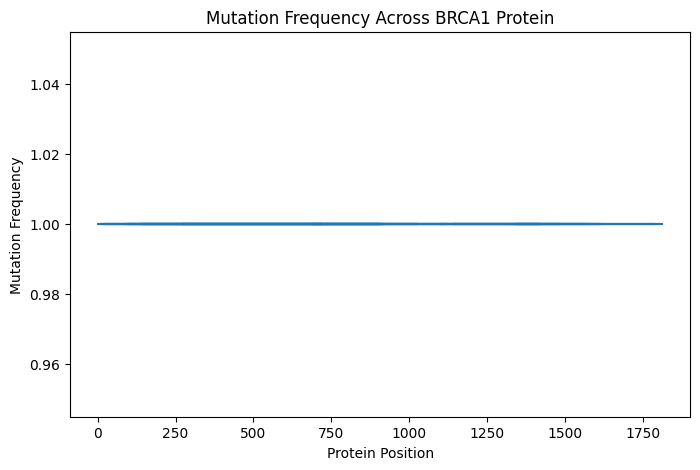


Validation Table:
   Known_driver_residue  Mutations_found
0                    24                0
1                  1756                0
2                  1775                0


In [6]:
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
import matplotlib.pyplot as plt

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("BRCA1_localized_mutations.csv")

df = df[df["Protein_Position"].notna()].copy()
df["Protein_Position"] = df["Protein_Position"].astype(int)
df["cDNA_Position"] = pd.to_numeric(df["cDNA_Position"], errors="coerce")

print("Total exonic mutations:", len(df))

# =====================================================
# LOAD CDS
# =====================================================

cds_record = SeqIO.read("BRCA1_cds_GRCh37.fasta", "fasta")
cds_seq = cds_record.seq

print("Protein length:", len(cds_seq)//3)

# =====================================================
# PART 1 — MUTATION TYPE CLASSIFICATION
# =====================================================

def classify_mutation(row):

    mut = str(row["Mutation"])
    prot_pos = int(row["Protein_Position"])
    cdna_pos = row["cDNA_Position"]

    if pd.isna(cdna_pos):
        return "Non-coding"

    if "-" in mut:
        ref, alt = mut.split(">")

        if len(ref) % 3 == 0 and len(alt) % 3 == 0:
            return "In-frame Indel"
        else:
            return "Frameshift"

    if ">" in mut and len(mut) == 3:

        ref_nt, alt_nt = mut.split(">")

        codon_index = prot_pos - 1
        codon_start = codon_index * 3

        if codon_start + 3 > len(cds_seq):
            return "Unknown"

        original_codon = cds_seq[codon_start:codon_start+3]
        original_aa = str(Seq(original_codon).translate())

        pos_in_codon = (int(cdna_pos) - cds_start_cdna) % 3
        mutated_codon = list(str(original_codon))
        mutated_codon[pos_in_codon] = alt_nt
        mutated_codon = "".join(mutated_codon)

        mutated_aa = str(Seq(mutated_codon).translate())

        if mutated_aa == original_aa:
            return "Silent"
        elif mutated_aa == "*":
            return "Nonsense"
        else:
            return "Missense"

    return "Complex"


df["Mutation_Type"] = df.apply(classify_mutation, axis=1)

mut_summary = df["Mutation_Type"].value_counts().reset_index()
mut_summary.columns = ["Mutation_Type", "Count"]
mut_summary["Percentage"] = (mut_summary["Count"]/mut_summary["Count"].sum())*100

print("\nMutation Type Summary Table:")
print(mut_summary)

mut_summary.to_csv("BRCA1_Mutation_Type_Summary.csv", index=False)

# =====================================================
# PART 2 — DOMAIN DISTRIBUTION
# =====================================================

def map_domain(pos):

    if 24 <= pos <= 65:
        return "RING"

    elif 1646 <= pos <= 1736:
        return "BRCT_1"

    elif 1760 <= pos <= 1855:
        return "BRCT_2"

    else:
        return "Other"


df["Domain"] = df["Protein_Position"].apply(map_domain)

domain_ranges = {
    "RING": "24–65",
    "BRCT_1": "1646–1736",
    "BRCT_2": "1760–1855",
    "Other": "Rest"
}

domain_counts = df["Domain"].value_counts().to_dict()

domain_table = []

for d in domain_ranges:

    count = domain_counts.get(d,0)

    if d=="RING": length=42
    elif d=="BRCT_1": length=91
    elif d=="BRCT_2": length=96
    else: length=1863-(42+91+96)

    density = round(count/length,4)

    domain_table.append([d,domain_ranges[d],count,density,""])

domain_df = pd.DataFrame(domain_table,
columns=["Domain","Residue_Range","Num_Mutations","Density","Remarks"])

print("\nDomain-wise Mutation Table:")
print(domain_df)

domain_df.to_csv("BRCA1_Domain_Distribution.csv", index=False)

# =====================================================
# PART 3 — HOTSPOT DETECTION
# =====================================================

freq = df["Protein_Position"].value_counts()

top10 = freq.head(10)

print("\nTop 10 Hotspot Residues:")
print(top10)

top10.to_csv("BRCA1_Top10_hotspots.csv")

plt.figure(figsize=(8,5))
freq.plot(kind="line")
plt.title("Mutation Frequency Across BRCA1 Protein")
plt.xlabel("Protein Position")
plt.ylabel("Mutation Frequency")
plt.show()

# =====================================================
# PART 4 — VALIDATION TABLE
# =====================================================

known_hotspots = [24, 1756, 1775]

validation_data = []

for pos in known_hotspots:

    count = df[df["Protein_Position"]==pos].shape[0]

    validation_data.append([pos,count])

validation_df = pd.DataFrame(validation_data,
columns=["Known_driver_residue","Mutations_found"])

print("\nValidation Table:")
print(validation_df)

validation_df.to_csv("BRCA1_Validation_hotspots.csv", index=False)

# =====================================================
# SAVE FINAL MASTER FILE
# =====================================================

df.to_csv("BRCA1_FINAL_COMPLETE.csv", index=False)

#KRAS

In [7]:
import pandas as pd
from bisect import bisect_left
from Bio import SeqIO

# ==============================
# LOAD REFERENCE DATA
# ==============================

print("Loading KRAS exon intervals...")
exon_df = pd.read_csv("/content/KRAS_exons_GRCh37.csv")

# Always keep genomic order for binary search
exon_df = exon_df.sort_values("Start").reset_index(drop=True)

STRAND = -1

exon_starts = exon_df["Start"].tolist()
exon_ends   = exon_df["End"].tolist()

# Create transcript order for cDNA offsets
if STRAND == -1:
    exon_starts_tx = exon_starts[::-1]
    exon_ends_tx   = exon_ends[::-1]
else:
    exon_starts_tx = exon_starts
    exon_ends_tx   = exon_ends

# Precompute cumulative exon lengths
exon_lengths = [abs(e - s) + 1 for s, e in zip(exon_starts_tx, exon_ends_tx)]

cdna_offsets = []
cum = 0
for length in exon_lengths:
    cdna_offsets.append(cum)
    cum += length

# ==============================
# LOAD SEQUENCES
# ==============================

cdna_seq = str(next(SeqIO.parse("/content/KRAS_cdna_GRCh37.fasta", "fasta")).seq)
cds_seq  = str(next(SeqIO.parse("/content/KRAS_cds_GRCh37.fasta", "fasta")).seq)

# Find CDS start inside cDNA sequence
cds_start_cdna = cdna_seq.find(cds_seq)
if cds_start_cdna == -1:
    raise ValueError("CDS sequence not found inside cDNA sequence!")

cds_start_cdna += 1
cds_end_cdna = cds_start_cdna + len(cds_seq) - 1

print(f"CDS spans cDNA positions: {cds_start_cdna}–{cds_end_cdna}")

# ==============================
# LOAD MUTATIONS
# ==============================

print("Loading mutation dataset...")
mut_df = pd.read_csv("/content/KRAS_mutations.csv")

KRAS_CHR = "12"
KRAS_START = min(exon_starts + exon_ends)
KRAS_END   = max(exon_starts + exon_ends)

# ==============================
# DIVIDE & CONQUER FUNCTIONS
# ==============================

def is_in_gene(pos):
    return KRAS_START <= pos <= KRAS_END


def find_exon_index(pos):

    idx = bisect_left(exon_starts, pos)

    if idx < len(exon_starts):
        low = min(exon_starts[idx], exon_ends[idx])
        high = max(exon_starts[idx], exon_ends[idx])
        if low <= pos <= high:
            return idx

    if idx > 0:
        low = min(exon_starts[idx-1], exon_ends[idx-1])
        high = max(exon_starts[idx-1], exon_ends[idx-1])
        if low <= pos <= high:
            return idx-1

    return None


def genomic_to_cdna(pos, exon_idx):

    if STRAND == -1:
        tx_idx = len(exon_starts) - 1 - exon_idx
    else:
        tx_idx = exon_idx

    s, e = exon_starts[exon_idx], exon_ends[exon_idx]
    offset = cdna_offsets[tx_idx]

    if STRAND == 1:
        return offset + (pos - s) + 1
    else:
        return offset + (e - pos) + 1


def cdna_to_protein(cdna_pos):
    if cds_start_cdna <= cdna_pos <= cds_end_cdna:
        return (cdna_pos - cds_start_cdna) // 3 + 1
    return None


# ==============================
# MAIN LOCALIZATION LOOP
# ==============================

print("Mapping mutations using divide-and-conquer...")

results = []

for _, row in mut_df.iterrows():
    chrom = str(row["Chromosome"])
    pos   = int(row["Position"])

    if chrom != KRAS_CHR or not is_in_gene(pos):
        continue

    exon_idx = find_exon_index(pos)

    region = "intron"
    cdna_pos = None
    protein_pos = None

    if exon_idx is not None:
        region = f"exon_{exon_idx+1}"
        cdna_pos = genomic_to_cdna(pos, exon_idx)
        protein_pos = cdna_to_protein(cdna_pos)

    results.append({
        "Mutation": f"{row['Ref']}>{row['Alt']}",
        "Genomic_Position": pos,
        "Region": region,
        "cDNA_Position": cdna_pos,
        "Protein_Position": protein_pos
    })

# ==============================
# OUTPUT RESULTS
# ==============================

out_df = pd.DataFrame(results)

print("\n===== KRAS Mutation Localization Results =====\n")
print(out_df)

out_df.to_csv("KRAS_localized_mutations.csv", index=False)
print("\nResults saved to KRAS_localized_mutations.csv")

Loading KRAS exon intervals...
CDS spans cDNA positions: 65–634
Loading mutation dataset...
Mapping mutations using divide-and-conquer...

===== KRAS Mutation Localization Results =====

   Mutation  Genomic_Position  Region  cDNA_Position  Protein_Position
0       C>A          25380184  exon_4            338              92.0
1       C>A          25398285  exon_5             98              12.0
2       C>A          25398284  exon_5             99              12.0
3       C>A          25398284  exon_5             99              12.0
4       C>T          25398284  exon_5             99              12.0
5       C>A          25398284  exon_5             99              12.0
6       G>T          25362626  exon_1            858               NaN
7  CTTTGT>-          25362744  exon_1            740               NaN

Results saved to KRAS_localized_mutations.csv


Total exonic mutations: 6
Protein length: 190
  Mutation_Type  Count  Percentage
0      Missense      6       100.0
        Domain Residue_Range  Num_Mutations  Density Remarks
0  GTP_binding         10–17              5   0.6250        
1     Switch_I         30–38              0   0.0000        
2    Switch_II         60–76              0   0.0000        
3        Other          Rest              1   0.0065        
Protein_Position
12    5
92    1
Name: count, dtype: int64


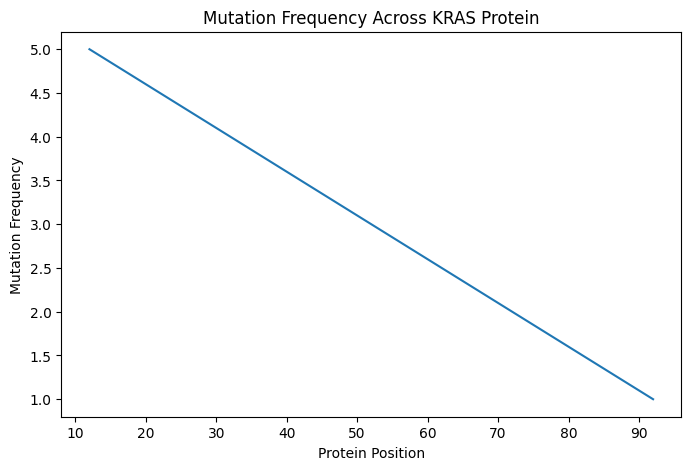

   Known_driver_residue  Mutations_found
0                    12                5
1                    13                0
2                    61                0


In [8]:
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
import matplotlib.pyplot as plt

df = pd.read_csv("KRAS_localized_mutations.csv")

df = df[df["Protein_Position"].notna()].copy()
df["Protein_Position"] = df["Protein_Position"].astype(int)
df["cDNA_Position"] = pd.to_numeric(df["cDNA_Position"], errors="coerce")

print("Total exonic mutations:", len(df))

cds_record = SeqIO.read("KRAS_cds_GRCh37.fasta", "fasta")
cds_seq = cds_record.seq

print("Protein length:", len(cds_seq)//3)

def classify_mutation(row):

    mut = str(row["Mutation"])
    prot_pos = int(row["Protein_Position"])
    cdna_pos = row["cDNA_Position"]

    if pd.isna(cdna_pos):
        return "Non-coding"

    if "-" in mut:
        ref, alt = mut.split(">")

        if len(ref) % 3 == 0 and len(alt) % 3 == 0:
            return "In-frame Indel"
        else:
            return "Frameshift"

    if ">" in mut and len(mut) == 3:

        ref_nt, alt_nt = mut.split(">")

        codon_index = prot_pos - 1
        codon_start = codon_index * 3

        if codon_start + 3 > len(cds_seq):
            return "Unknown"

        original_codon = cds_seq[codon_start:codon_start+3]
        original_aa = str(Seq(original_codon).translate())

        pos_in_codon = (int(cdna_pos) - cds_start_cdna) % 3
        mutated_codon = list(str(original_codon))
        mutated_codon[pos_in_codon] = alt_nt
        mutated_codon = "".join(mutated_codon)

        mutated_aa = str(Seq(mutated_codon).translate())

        if mutated_aa == original_aa:
            return "Silent"
        elif mutated_aa == "*":
            return "Nonsense"
        else:
            return "Missense"

    return "Complex"


df["Mutation_Type"] = df.apply(classify_mutation, axis=1)

mut_summary = df["Mutation_Type"].value_counts().reset_index()
mut_summary.columns = ["Mutation_Type", "Count"]
mut_summary["Percentage"] = (mut_summary["Count"]/mut_summary["Count"].sum())*100

print(mut_summary)

mut_summary.to_csv("KRAS_Mutation_Type_Summary.csv", index=False)

# DOMAIN MAPPING

def map_domain(pos):

    if 10 <= pos <= 17:
        return "GTP_binding"

    elif 30 <= pos <= 38:
        return "Switch_I"

    elif 60 <= pos <= 76:
        return "Switch_II"

    else:
        return "Other"


df["Domain"] = df["Protein_Position"].apply(map_domain)

domain_ranges = {
"GTP_binding":"10–17",
"Switch_I":"30–38",
"Switch_II":"60–76",
"Other":"Rest"
}

domain_counts = df["Domain"].value_counts().to_dict()

domain_table=[]

for d in domain_ranges:

    count=domain_counts.get(d,0)

    if d=="GTP_binding": length=8
    elif d=="Switch_I": length=9
    elif d=="Switch_II": length=17
    else: length=188-(8+9+17)

    density=round(count/length,4)

    domain_table.append([d,domain_ranges[d],count,density,""])

domain_df=pd.DataFrame(domain_table,
columns=["Domain","Residue_Range","Num_Mutations","Density","Remarks"])

print(domain_df)

domain_df.to_csv("KRAS_Domain_Distribution.csv",index=False)

freq=df["Protein_Position"].value_counts()

top10=freq.head(10)

print(top10)

top10.to_csv("KRAS_Top10_hotspots.csv")

plt.figure(figsize=(8,5))
freq.plot(kind="line")
plt.title("Mutation Frequency Across KRAS Protein")
plt.xlabel("Protein Position")
plt.ylabel("Mutation Frequency")
plt.show()

known_hotspots=[12,13,61]

validation_data=[]

for pos in known_hotspots:

    count=df[df["Protein_Position"]==pos].shape[0]

    validation_data.append([pos,count])

validation_df=pd.DataFrame(validation_data,
columns=["Known_driver_residue","Mutations_found"])

print(validation_df)

validation_df.to_csv("KRAS_Validation_hotspots.csv",index=False)

df.to_csv("KRAS_FINAL_COMPLETE.csv",index=False)